In [1]:
print("Netflix Data Analysis")

Netflix Data Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [6]:
import zipfile
import os

zip_file = "archive.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("/content/netflix_data")

print("ZIP file extracted successfully!")
print(os.listdir("/content/netflix_data"))

ZIP file extracted successfully!
['netflix_titles.csv']


In [7]:
df = pd.read_csv("/content/netflix_data/netflix_titles.csv")

print("Dataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and Columns: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
print("Statistical Summary:")
df.describe(include="all")

Statistical Summary:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [12]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent.round(2)
})

missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


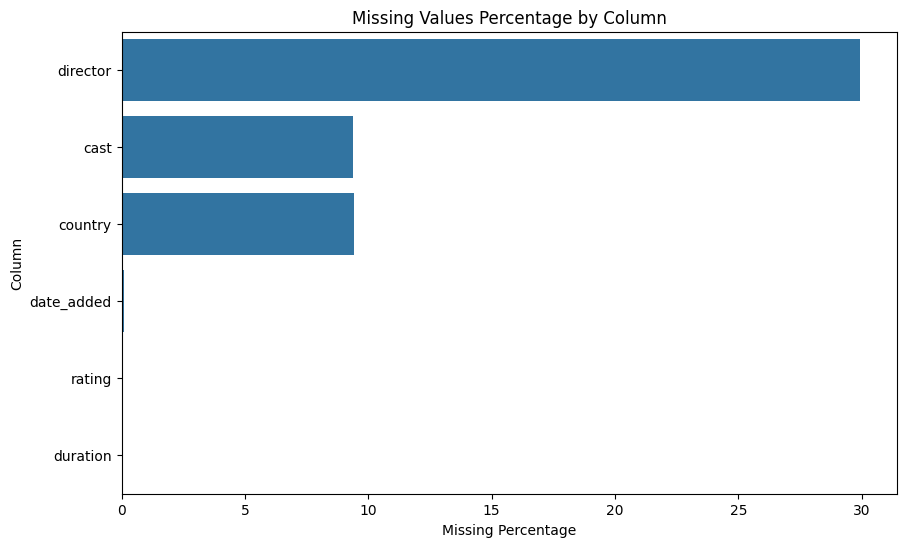

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_data['Percentage'],
    y=missing_data.index
)

plt.title('Missing Values Percentage by Column')
plt.xlabel('Missing Percentage')
plt.ylabel('Column')
plt.show()

In [14]:
fill_columns = ['director', 'cast', 'country']

for col in fill_columns:
    df[col] = df[col].fillna('Unknown')

print("Missing values filled successfully!")

Missing values filled successfully!


In [15]:
df['date_added'] = df['date_added'].fillna('Unknown')

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          4
duration        3
listed_in       0
description     0
dtype: int64


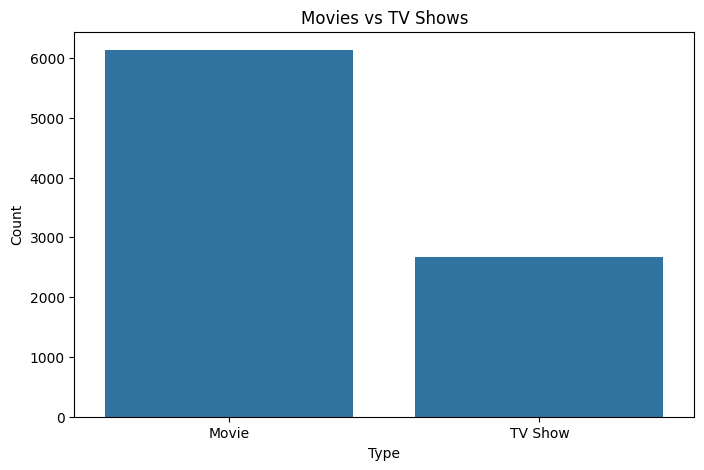

In [16]:
# Data Visualization

plt.figure(figsize=(8,5))

sns.countplot(data=df, x='type')

plt.title('Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

plt.show()

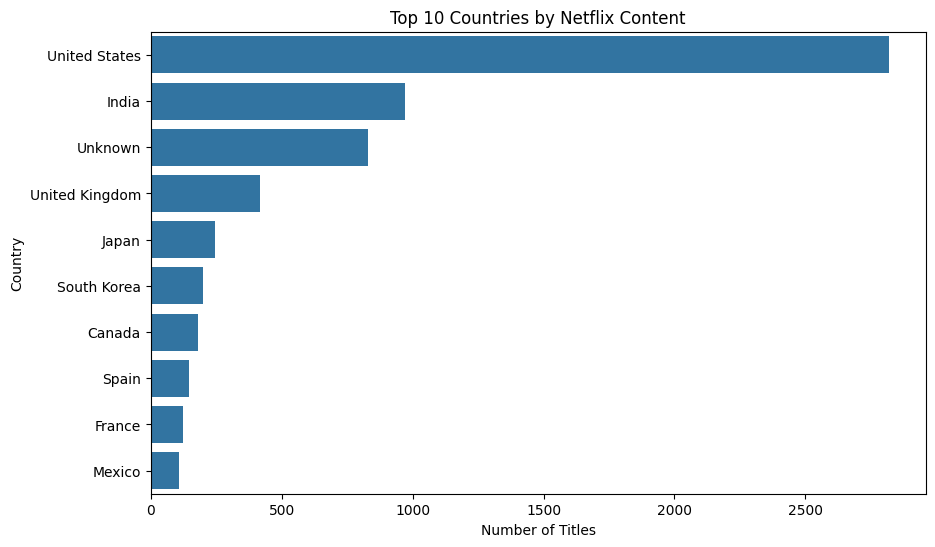

In [17]:
# Top 10 Countries with Most Netflix Content

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

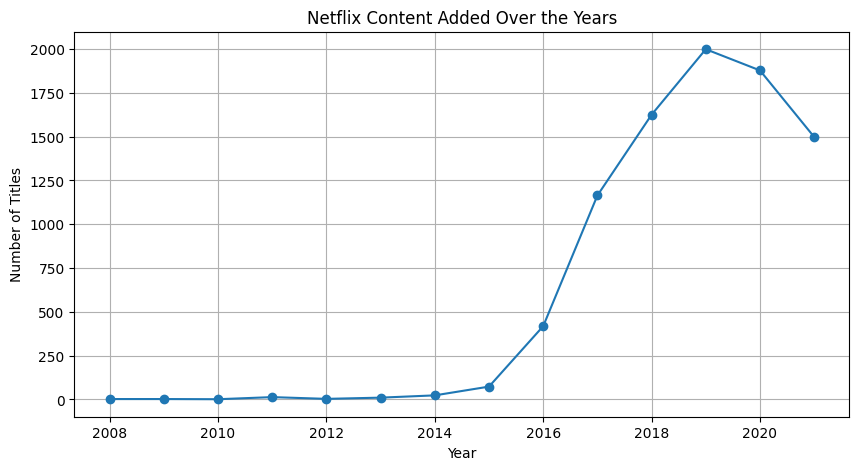

In [18]:
# Content Added Over the Years

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

year_added = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(year_added.index, year_added.values, marker='o')

plt.title('Netflix Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.show()

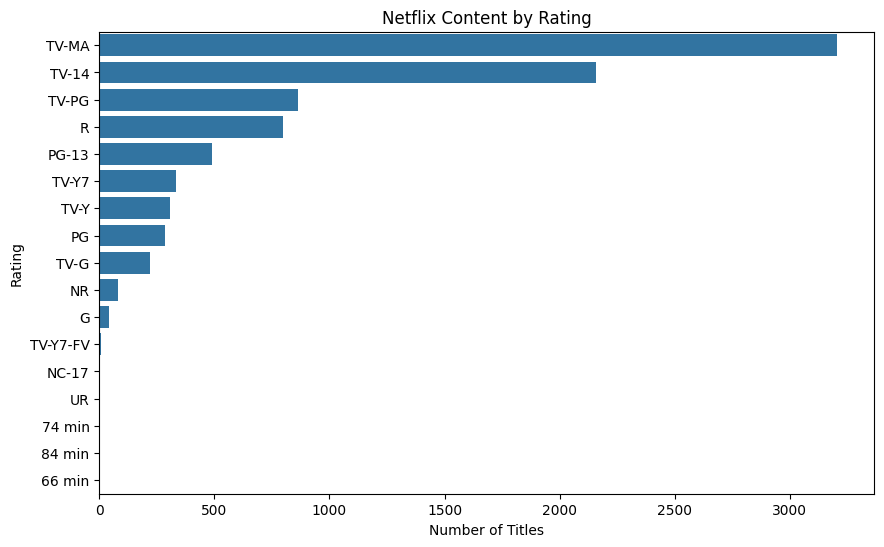

In [19]:
# Ratings Distribution

plt.figure(figsize=(10,6))

sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index)

plt.title('Netflix Content by Rating')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')

plt.show()

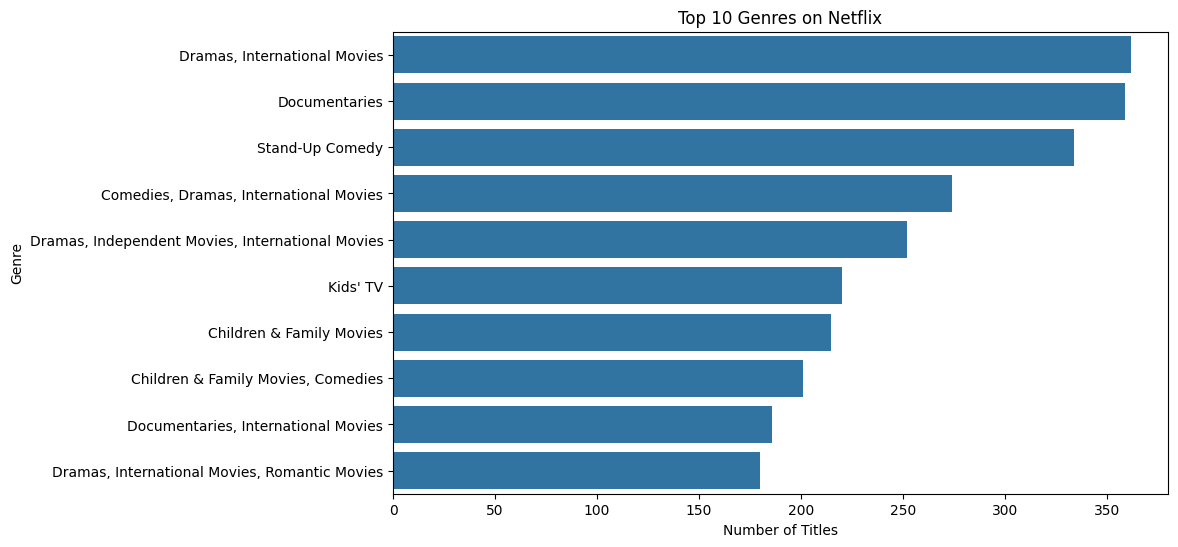

In [20]:
# Top 10 Genres on Netflix

genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=genres.values, y=genres.index)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

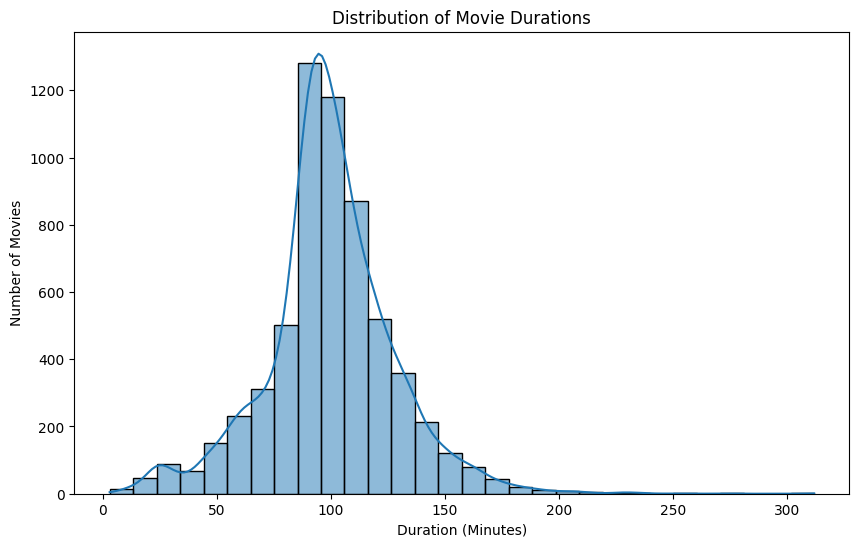

In [21]:
# Movie Duration Analysis

movies = df[df['type'] == 'Movie'].copy()

movies['duration_min'] = movies['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10,6))

sns.histplot(movies['duration_min'].dropna(), bins=30, kde=True)

plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')

plt.show()

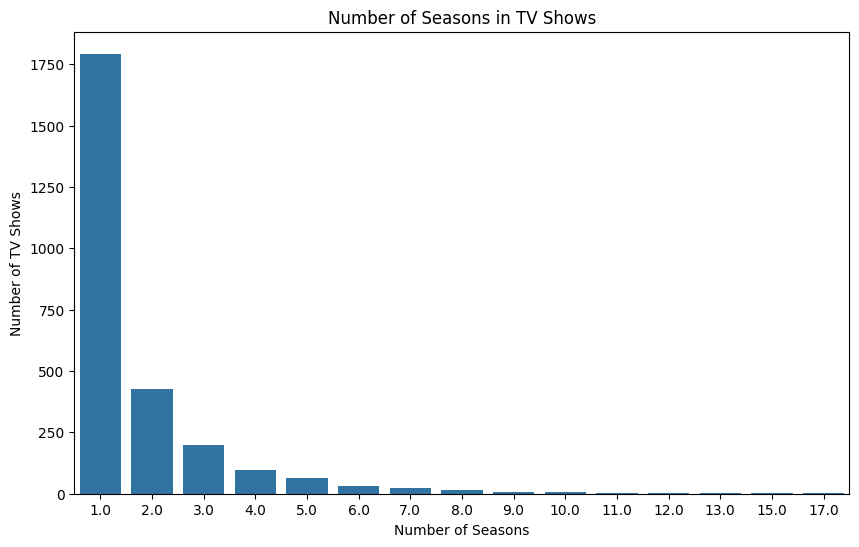

In [22]:
# TV Shows Season Analysis

tv_shows = df[df['type'] == 'TV Show'].copy()

tv_shows['seasons'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10,6))

sns.countplot(
    data=tv_shows,
    x='seasons',
    order=sorted(tv_shows['seasons'].dropna().unique())
)

plt.title('Number of Seasons in TV Shows')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.show()

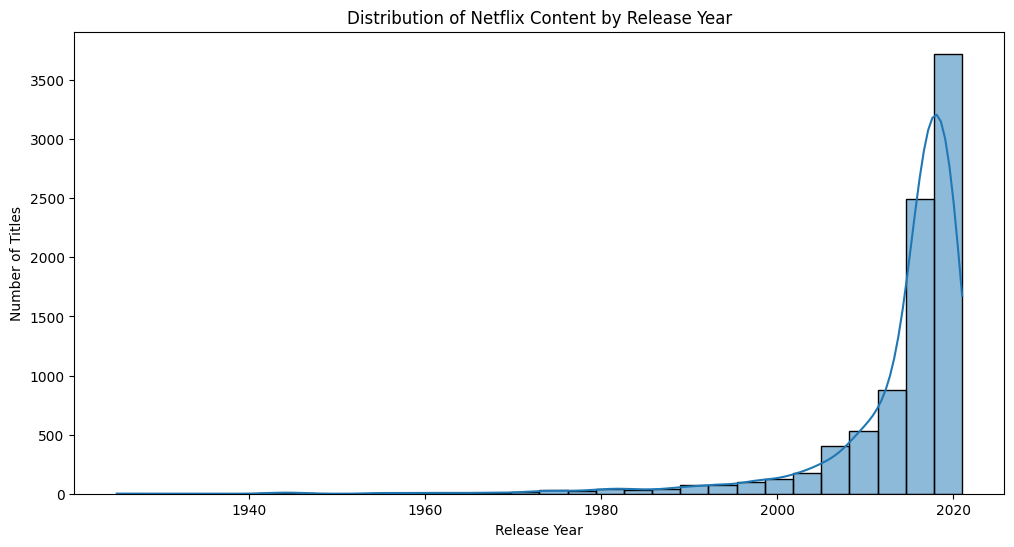

In [23]:
# Release Year Analysis

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x='release_year',
    bins=30,
    kde=True
)

plt.title('Distribution of Netflix Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

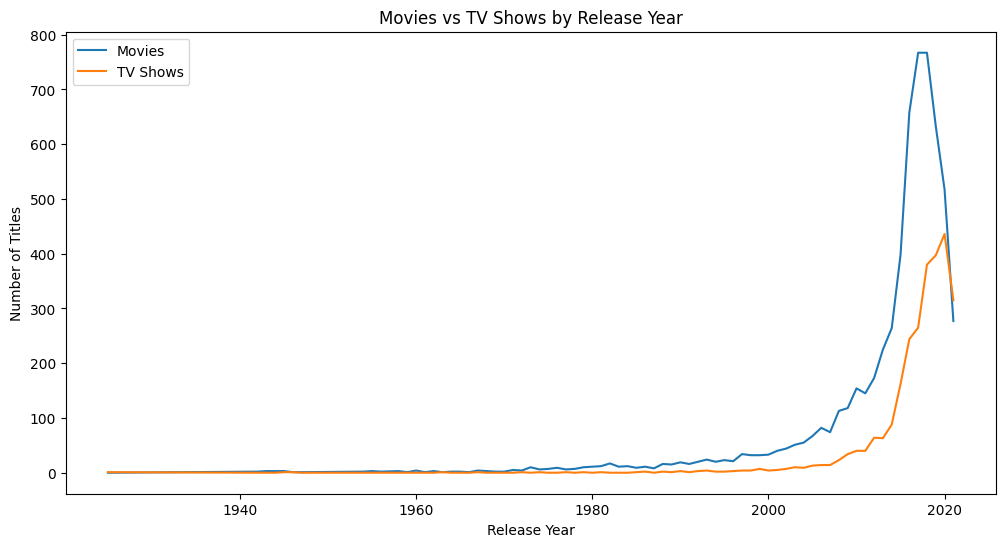

In [24]:
# Movies vs TV Shows by Release Year

year_type = df.groupby(['release_year', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))

plt.plot(
    year_type.index,
    year_type['Movie'],
    label='Movies'
)

plt.plot(
    year_type.index,
    year_type['TV Show'],
    label='TV Shows'
)

plt.title('Movies vs TV Shows by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()

plt.show()

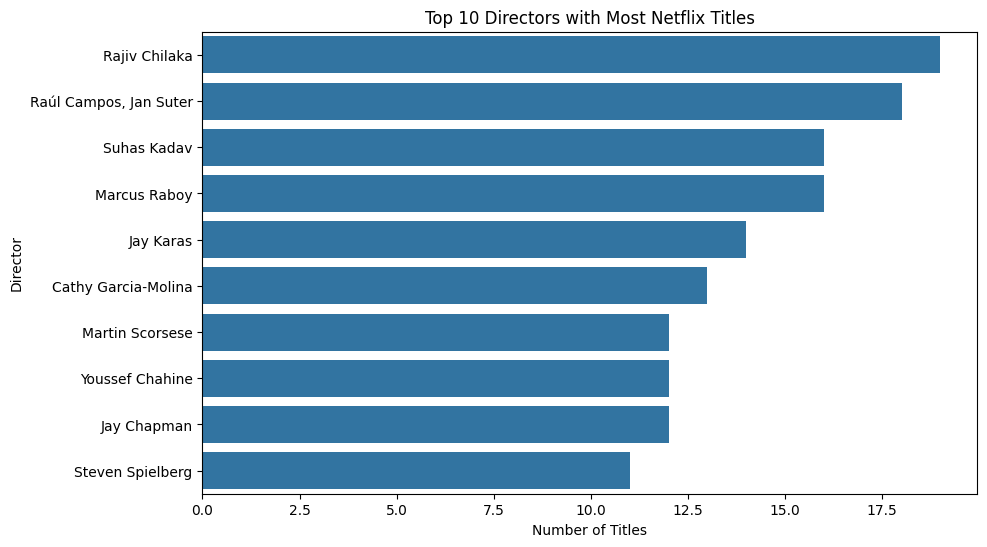

In [25]:
# Top 10 Directors on Netflix

top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title('Top 10 Directors with Most Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.show()

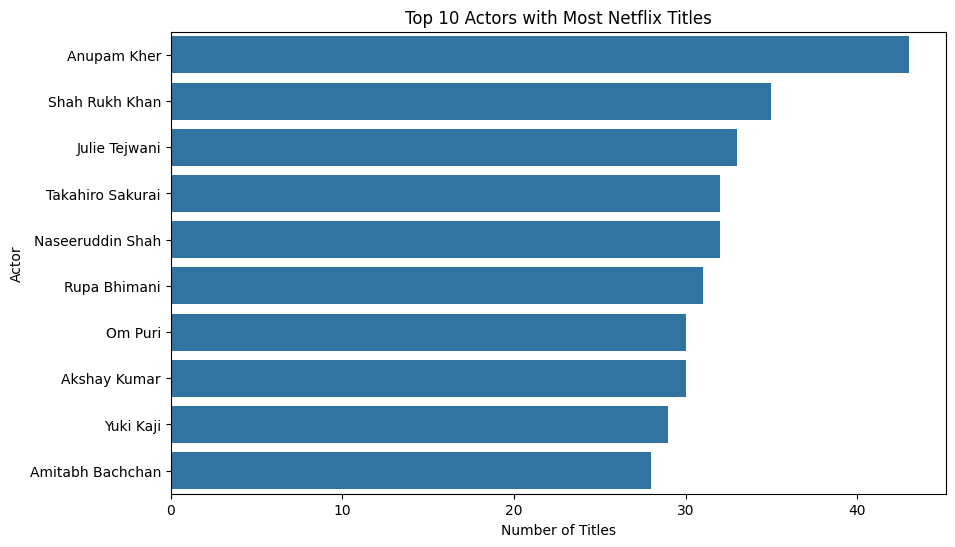

In [26]:
# Top 10 Actors on Netflix

cast_data = df[df['cast'] != 'Unknown']['cast'].str.split(',').explode()

top_actors = cast_data.str.strip().value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_actors.values,
    y=top_actors.index
)

plt.title('Top 10 Actors with Most Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')

plt.show()

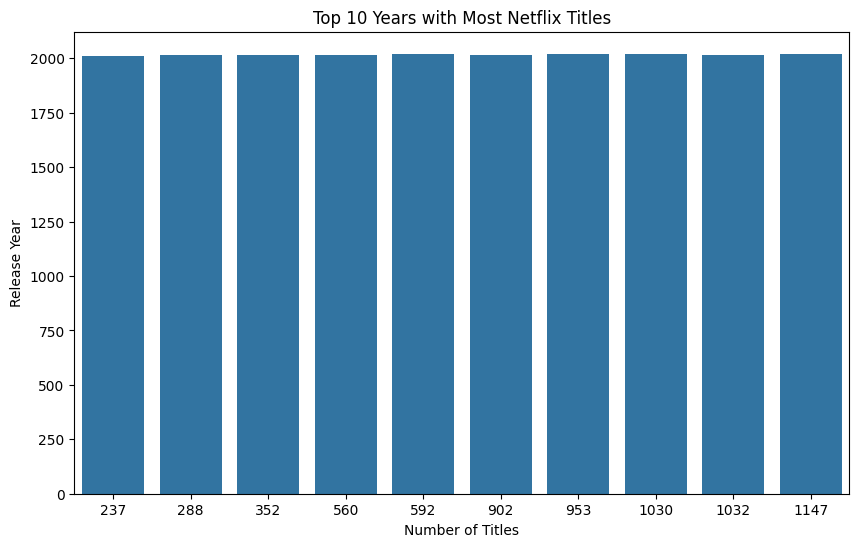

In [27]:
# Top 10 Release Years

top_years = df['release_year'].value_counts().head(10).sort_values()

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_years.values,
    y=top_years.index
)

plt.title('Top 10 Years with Most Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Release Year')

plt.show()

In [28]:
# Movies vs TV Shows - Count and Percentage

type_count = df['type'].value_counts()
type_percentage = (type_count / len(df) * 100).round(2)

summary = pd.DataFrame({
    'Count': type_count,
    'Percentage': type_percentage
})

summary

,Count,Percentage
type,,
Movie,6131,69.62
TV Show,2676,30.38


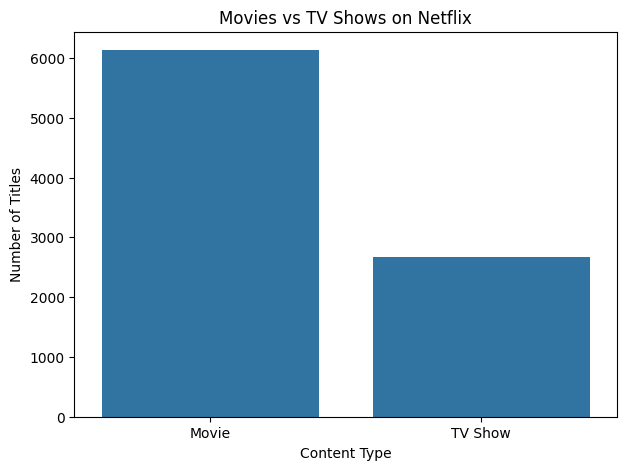

In [29]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=type_count.index,
    y=type_count.values
)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.show()

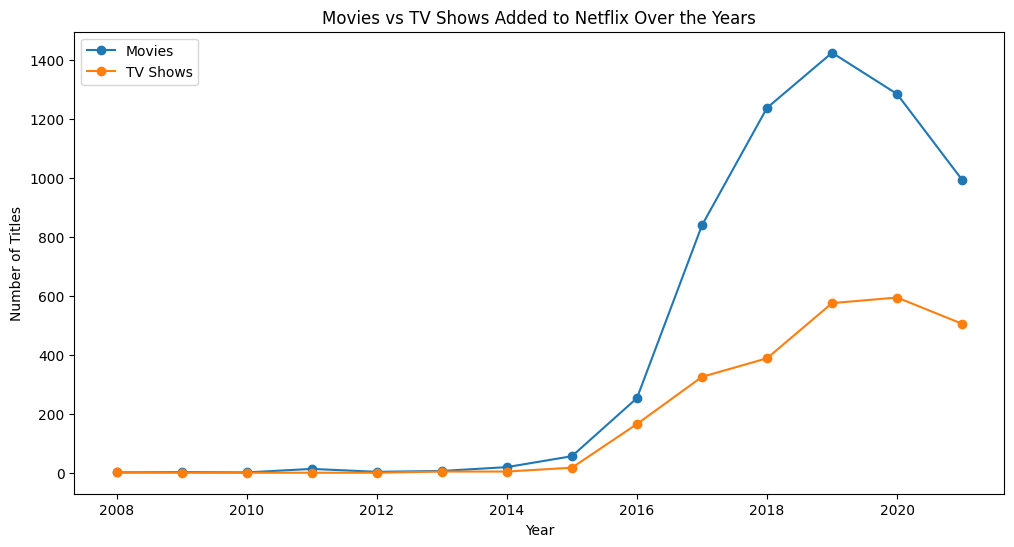

In [30]:
# Movies vs TV Shows Added Over the Years

content_added = df.dropna(subset=['date_added']).copy()

content_added['added_year'] = content_added['date_added'].dt.year

year_type = (
    content_added
    .groupby(['added_year', 'type'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))

plt.plot(
    year_type.index,
    year_type['Movie'],
    marker='o',
    label='Movies'
)

plt.plot(
    year_type.index,
    year_type['TV Show'],
    marker='o',
    label='TV Shows'
)

plt.title('Movies vs TV Shows Added to Netflix Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend()

plt.show()

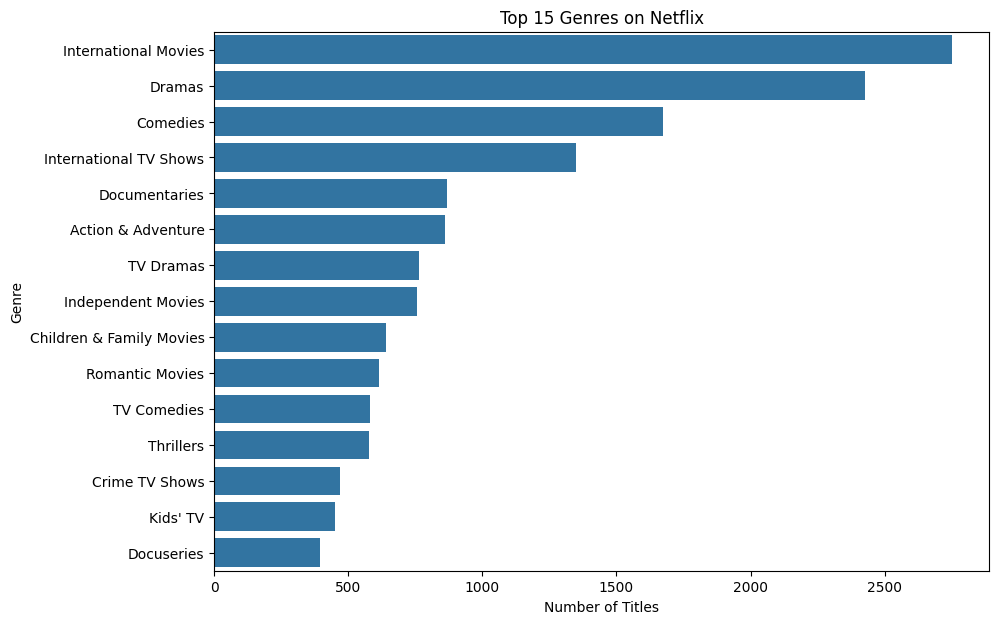

In [31]:
# Top 15 Individual Genres

genre_data = df[df['listed_in'].notna()]['listed_in'].str.split(',').explode()

genre_data = genre_data.str.strip()

top_genres = genre_data.value_counts().head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 15 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()

<Figure size 1200x600 with 0 Axes>

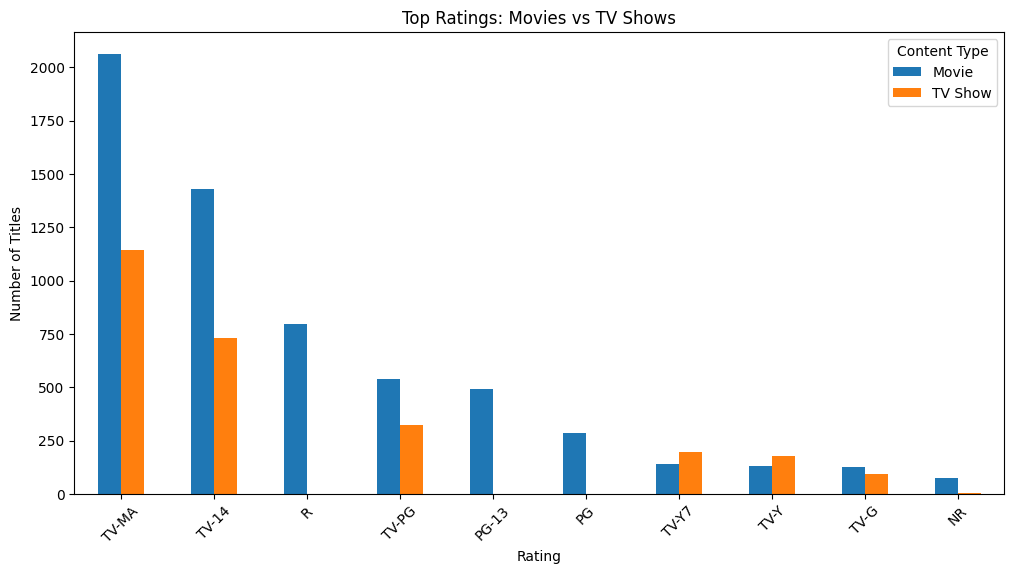

In [32]:
# Rating Distribution: Movies vs TV Shows

rating_type = (
    df.dropna(subset=['rating'])
      .groupby(['rating', 'type'])
      .size()
      .unstack(fill_value=0)
)

rating_type = rating_type.sort_values(
    by=rating_type.columns.tolist(),
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

rating_type.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top Ratings: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.show()

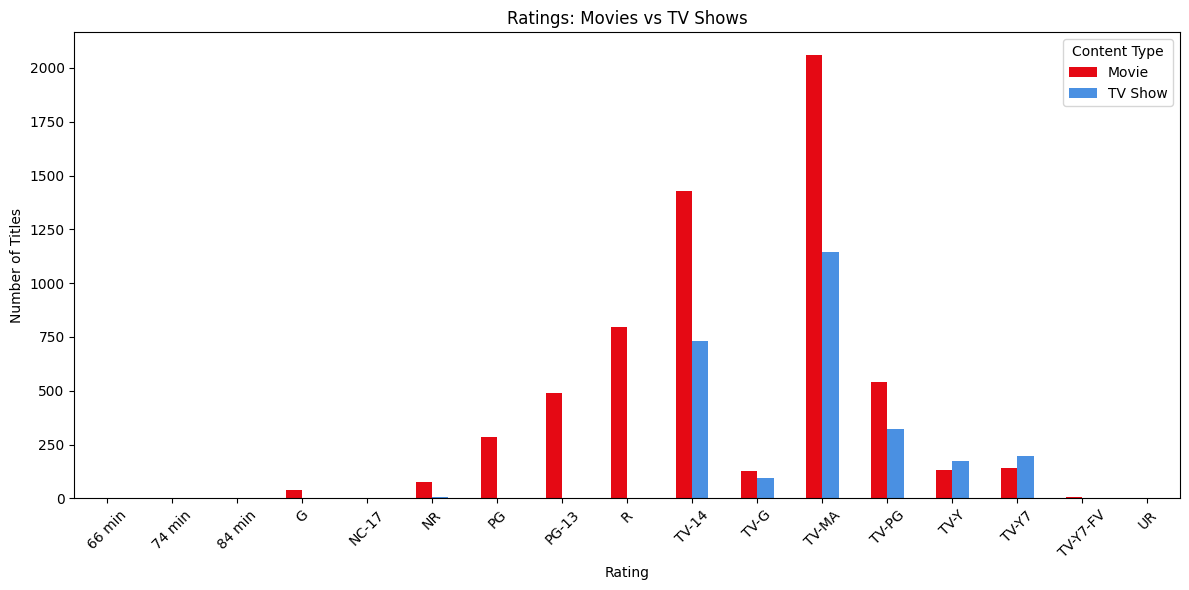

In [33]:
# Rating Distribution: Movies vs TV Shows

rating_type = (
    df.dropna(subset=['rating'])
      .groupby(['rating', 'type'])
      .size()
      .unstack(fill_value=0)
)

rating_type.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#E50914', '#4A90E2']
)

plt.title('Ratings: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

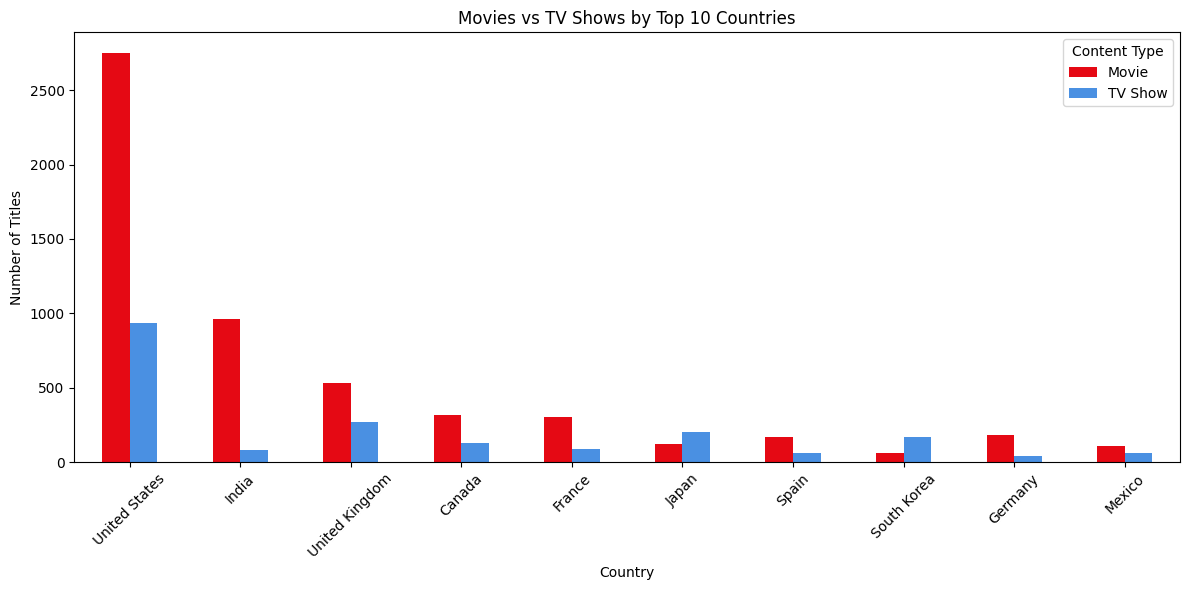

In [34]:
country_type = (
    df[df['country'] != 'Unknown']
    .assign(country=df['country'].str.split(','))
    .explode('country')
)

country_type['country'] = country_type['country'].str.strip()

top_countries = country_type['country'].value_counts().head(10).index

country_type_top = country_type[
    country_type['country'].isin(top_countries)
]

country_type_grouped = (
    country_type_top
    .groupby(['country', 'type'])
    .size()
    .unstack(fill_value=0)
)

country_type_grouped = country_type_grouped.loc[
    country_type_grouped.sum(axis=1).sort_values(ascending=False).index
]

country_type_grouped.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#E50914', '#4A90E2']
)

plt.title('Movies vs TV Shows by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

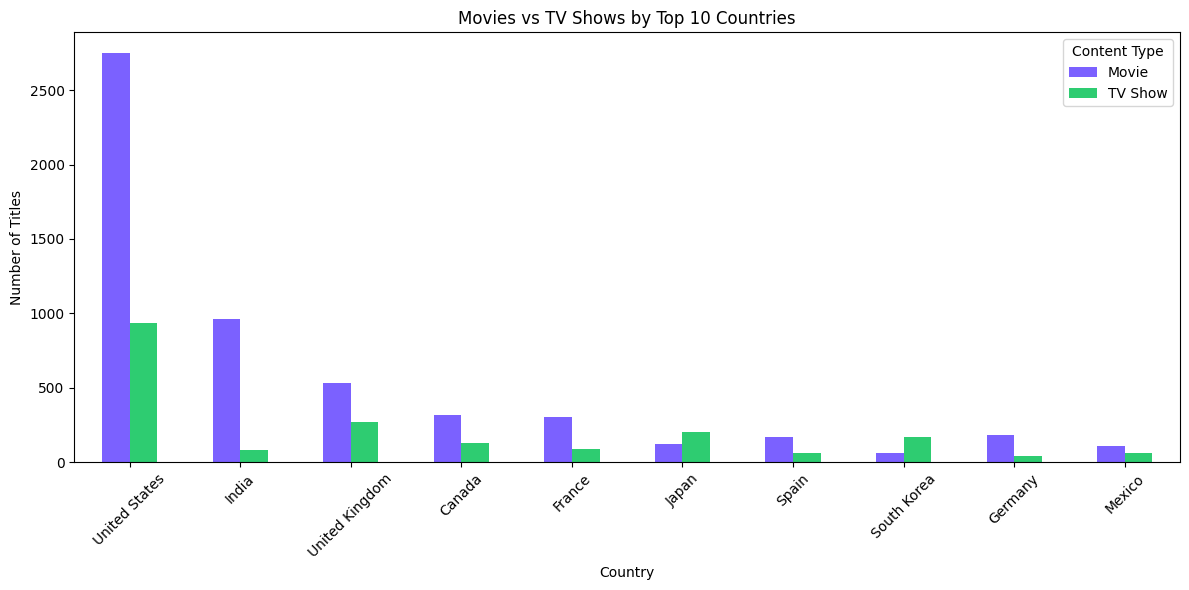

In [35]:
country_type = (
    df[df['country'] != 'Unknown']
    .assign(country=df['country'].str.split(','))
    .explode('country')
)

country_type['country'] = country_type['country'].str.strip()

top_countries = country_type['country'].value_counts().head(10).index

country_type_top = country_type[
    country_type['country'].isin(top_countries)
]

country_type_grouped = (
    country_type_top
    .groupby(['country', 'type'])
    .size()
    .unstack(fill_value=0)
)

country_type_grouped = country_type_grouped.loc[
    country_type_grouped.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

country_type_grouped.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#7B61FF', '#2ECC71']
)

plt.title('Movies vs TV Shows by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

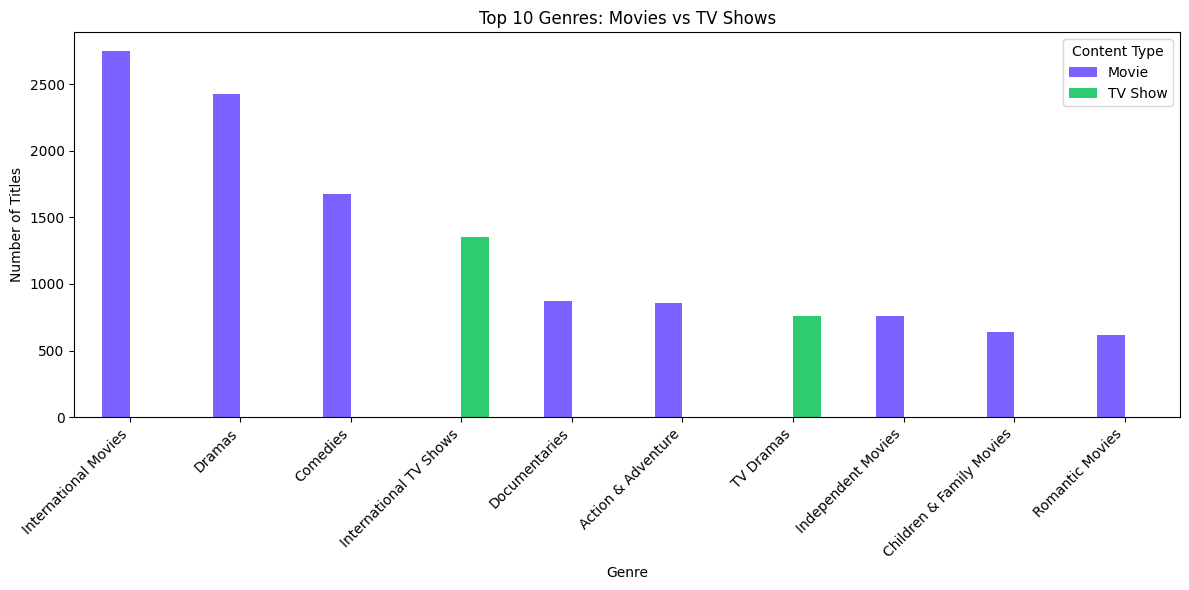

In [36]:
genre_type = (
    df[df['listed_in'].notna()]
    .assign(genre=df['listed_in'].str.split(','))
    .explode('genre')
)

genre_type['genre'] = genre_type['genre'].str.strip()

top_genres = genre_type['genre'].value_counts().head(10).index

genre_type_top = genre_type[
    genre_type['genre'].isin(top_genres)
]

genre_type_grouped = (
    genre_type_top
    .groupby(['genre', 'type'])
    .size()
    .unstack(fill_value=0)
)

genre_type_grouped = genre_type_grouped.loc[
    genre_type_grouped.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

genre_type_grouped.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#7B61FF', '#2ECC71']
)

plt.title('Top 10 Genres: Movies vs TV Shows')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

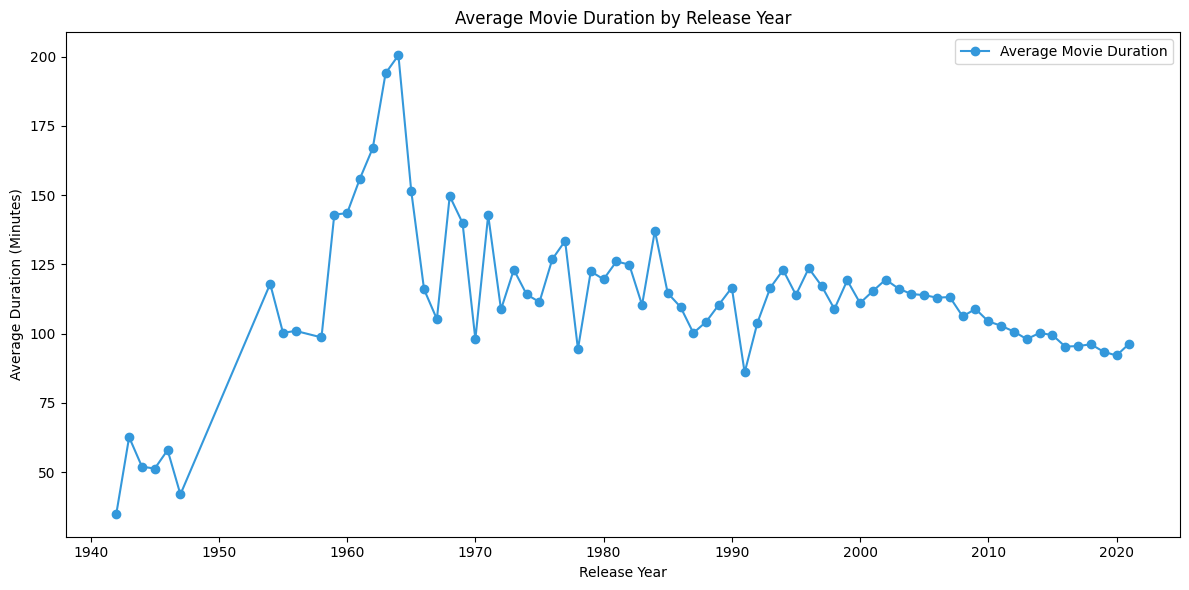

In [37]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_min'] = (
    movies['duration']
    .str.extract(r'(\d+)')
    .astype(float)
)

duration_year = (
    movies.dropna(subset=['duration_min'])
    .groupby('release_year')['duration_min']
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    duration_year.index,
    duration_year.values,
    marker='o',
    color='#3498DB',
    label='Average Movie Duration'
)

plt.title('Average Movie Duration by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (Minutes)')
plt.legend()

plt.tight_layout()
plt.show()

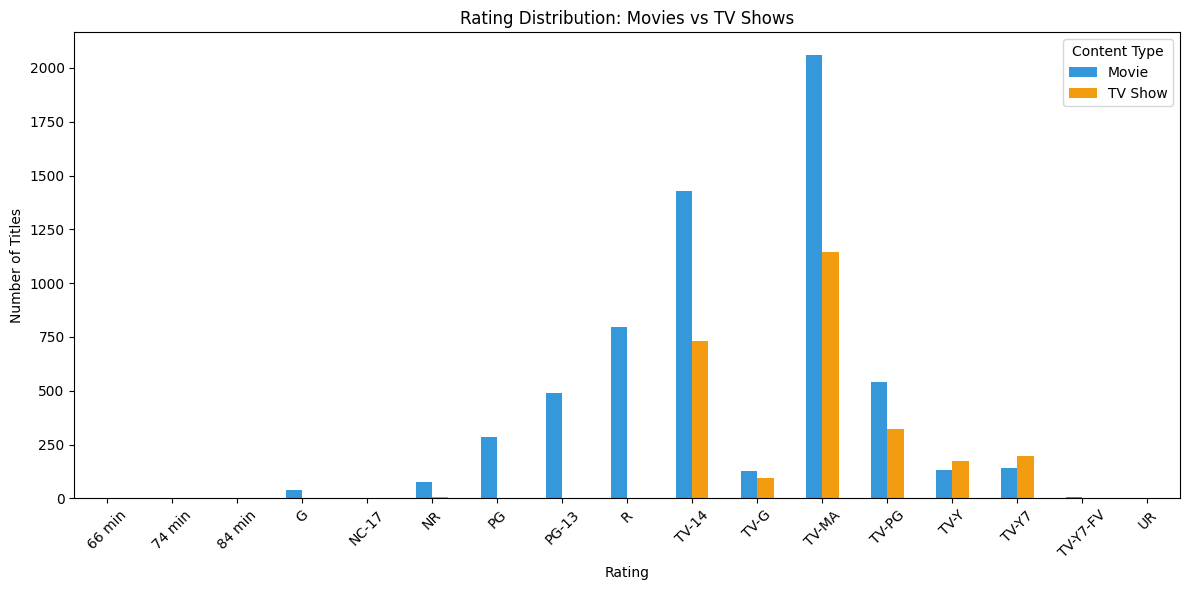

In [38]:
rating_type = (
    df.dropna(subset=['rating'])
      .groupby(['rating', 'type'])
      .size()
      .unstack(fill_value=0)
)

rating_type.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#3498DB', '#F39C12']
)

plt.title('Rating Distribution: Movies vs TV Shows')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

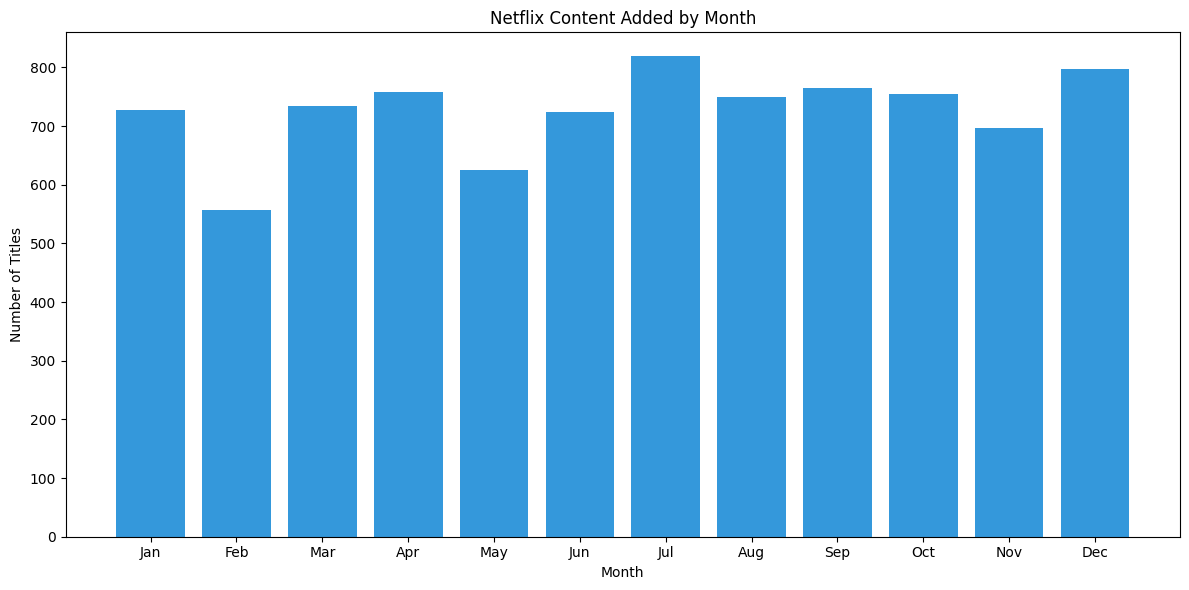

In [39]:
month_added = df.dropna(subset=['date_added']).copy()

month_added['month'] = month_added['date_added'].dt.month

monthly_content = (
    month_added['month']
    .value_counts()
    .sort_index()
)

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

monthly_content.index = [
    month_names[i - 1] for i in monthly_content.index
]

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_content.index,
    monthly_content.values,
    color='#3498DB'
)

plt.title('Netflix Content Added by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

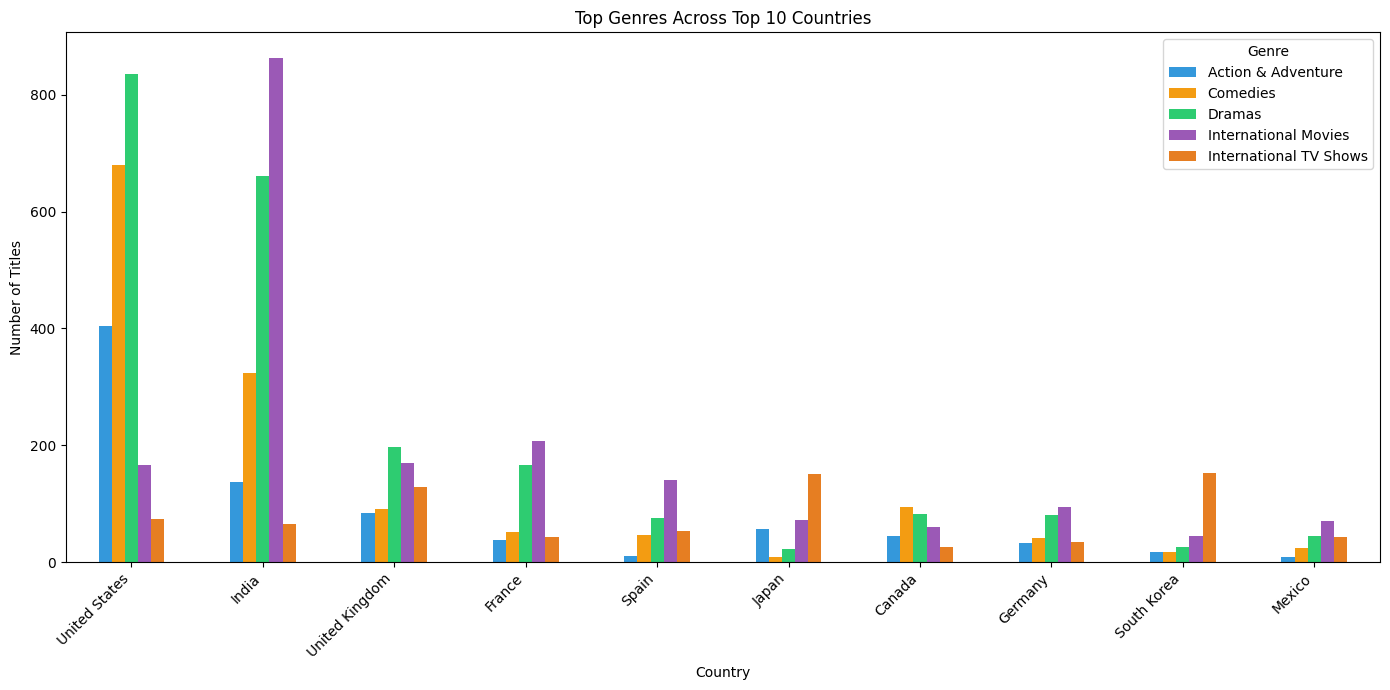

In [40]:
country_genre = (
    df[df['country'] != 'Unknown']
    .assign(country=df['country'].str.split(','))
    .explode('country')
)

country_genre['country'] = country_genre['country'].str.strip()

country_genre = (
    country_genre
    .assign(genre=country_genre['listed_in'].str.split(','))
    .explode('genre')
)

country_genre['genre'] = country_genre['genre'].str.strip()

top_countries = country_genre['country'].value_counts().head(10).index
top_genres = country_genre['genre'].value_counts().head(5).index

data = country_genre[
    country_genre['country'].isin(top_countries) &
    country_genre['genre'].isin(top_genres)
]

pivot_data = pd.crosstab(
    data['country'],
    data['genre']
)

pivot_data = pivot_data.loc[
    pivot_data.sum(axis=1).sort_values(ascending=False).index
]

pivot_data.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#3498DB', '#F39C12', '#2ECC71', '#9B59B6', '#E67E22']
)

plt.title('Top Genres Across Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Genre')

plt.tight_layout()
plt.show()

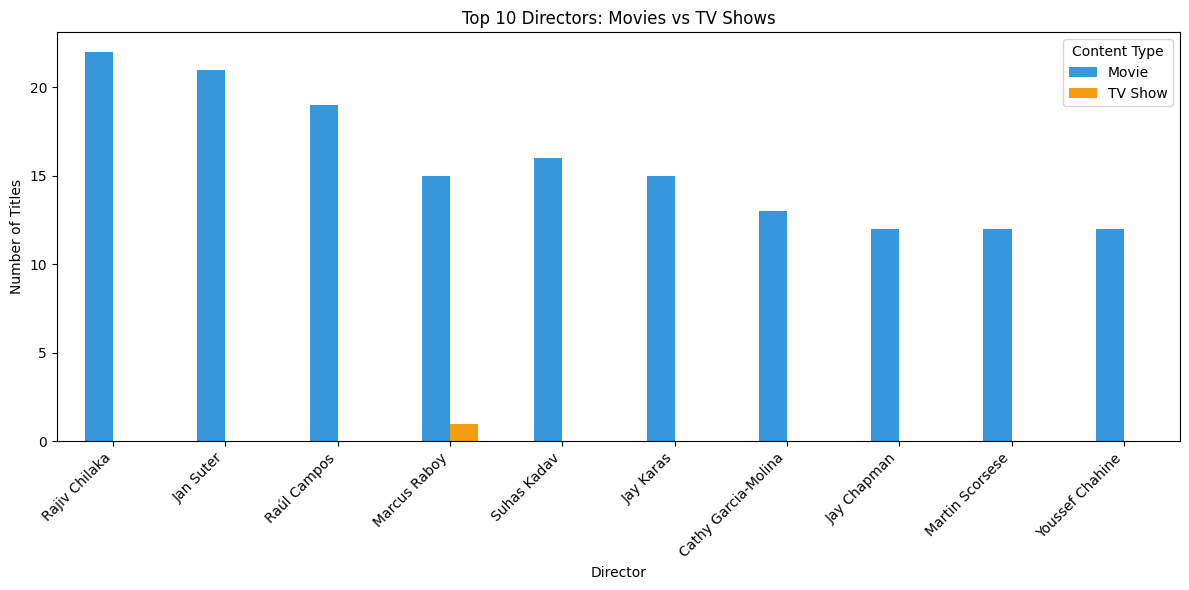

In [41]:
director_type = (
    df[df['director'] != 'Unknown']
    .assign(director=df['director'].str.split(','))
    .explode('director')
)

director_type['director'] = director_type['director'].str.strip()

top_directors = (
    director_type['director']
    .value_counts()
    .head(10)
    .index
)

director_data = director_type[
    director_type['director'].isin(top_directors)
]

director_grouped = (
    director_data
    .groupby(['director', 'type'])
    .size()
    .unstack(fill_value=0)
)

director_grouped = director_grouped.loc[
    director_grouped.sum(axis=1)
    .sort_values(ascending=False)
    .index
]

director_grouped.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#3498DB', '#F39C12']
)

plt.title('Top 10 Directors: Movies vs TV Shows')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')

plt.tight_layout()
plt.show()

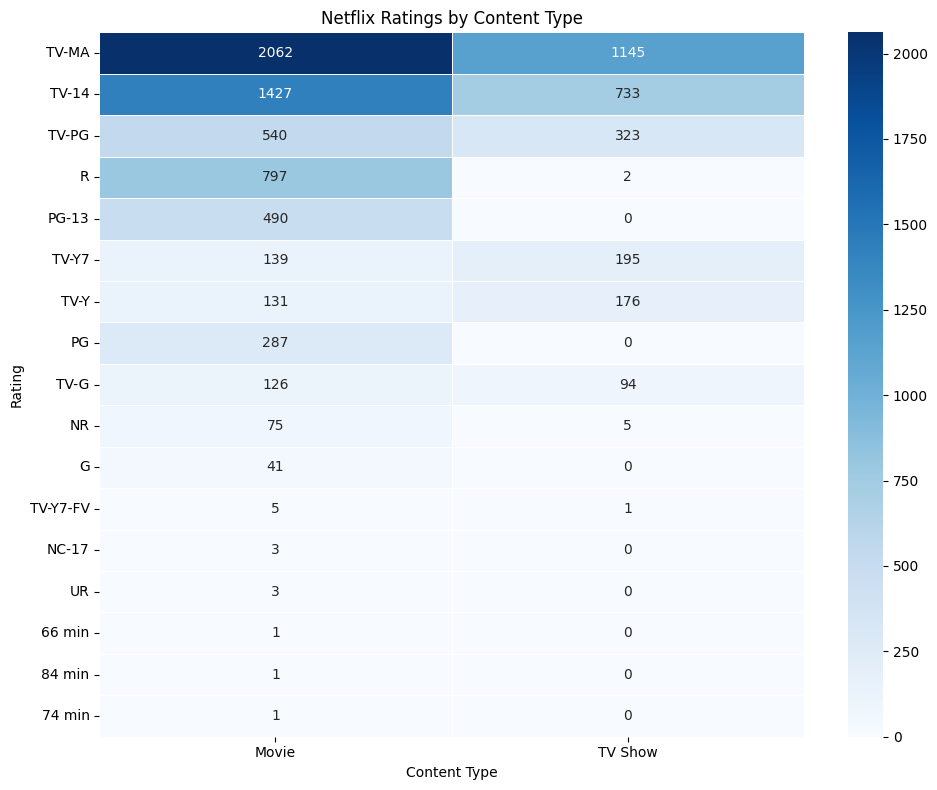

In [44]:
rating_heatmap = (
    df.dropna(subset=['rating'])
      .groupby(['rating', 'type'])
      .size()
      .unstack(fill_value=0)
)

# Ratings ko total titles ke according sort karna
rating_heatmap = rating_heatmap.loc[
    rating_heatmap.sum(axis=1).sort_values(ascending=False).index
]

plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Netflix Ratings by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

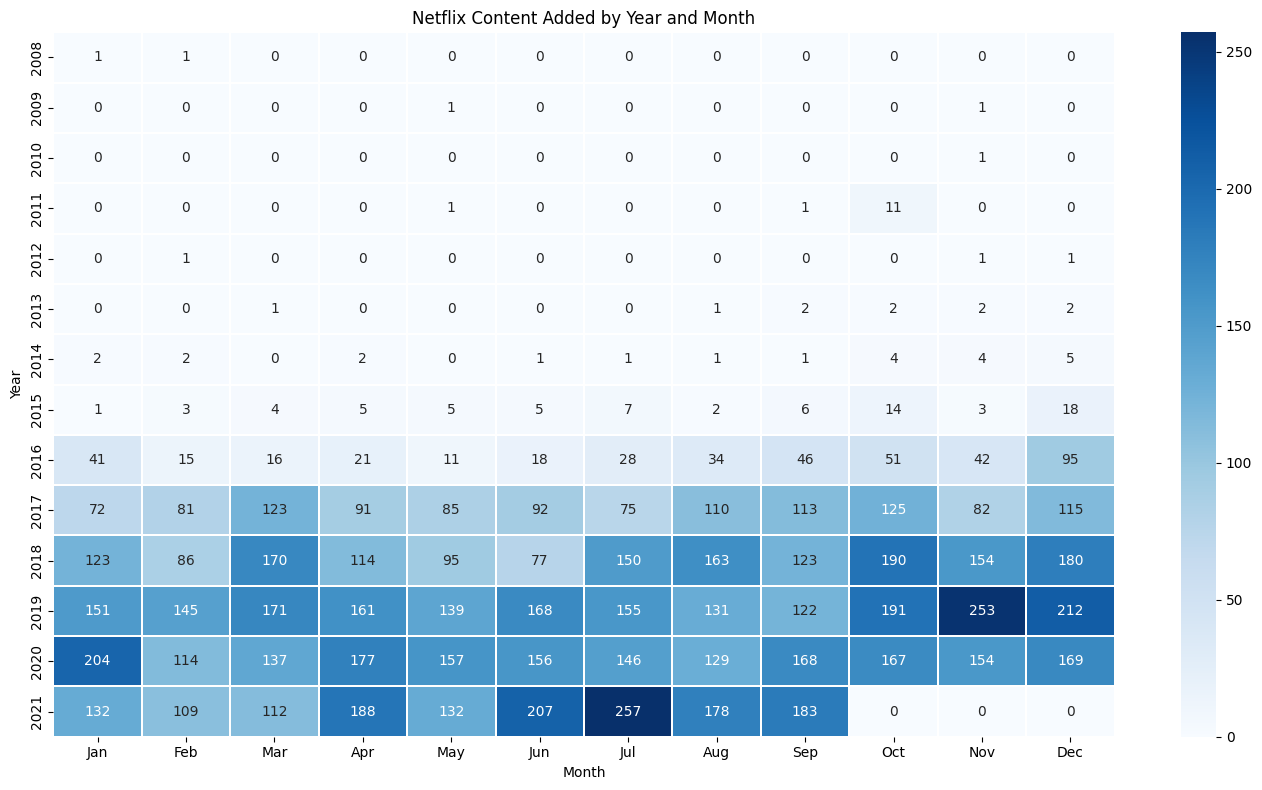

In [43]:
content_time = df.dropna(subset=['date_added']).copy()

content_time['year'] = content_time['date_added'].dt.year
content_time['month'] = content_time['date_added'].dt.month

year_month = pd.crosstab(
    content_time['year'],
    content_time['month']
)

year_month = year_month.reindex(columns=range(1, 13), fill_value=0)

year_month.columns = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(14, 8))

sns.heatmap(
    year_month,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.3
)

plt.title('Netflix Content Added by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')

plt.tight_layout()
plt.show()

In [45]:
total_titles = len(df)

total_movies = (df['type'] == 'Movie').sum()
total_tv_shows = (df['type'] == 'TV Show').sum()

total_countries = (
    df[df['country'] != 'Unknown']['country']
    .str.split(',')
    .explode()
    .str.strip()
    .nunique()
)

total_genres = (
    df['listed_in']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .nunique()
)

latest_release_year = df['release_year'].max()

oldest_release_year = df['release_year'].min()

average_movie_duration = movies['duration_min'].mean()

average_tv_seasons = tv_shows['seasons'].mean()

kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Titles',
        'Total Movies',
        'Total TV Shows',
        'Total Countries',
        'Total Genres',
        'Latest Release Year',
        'Oldest Release Year',
        'Average Movie Duration (min)',
        'Average TV Show Seasons'
    ],
    'Value': [
        total_titles,
        total_movies,
        total_tv_shows,
        total_countries,
        total_genres,
        latest_release_year,
        oldest_release_year,
        round(average_movie_duration, 2),
        round(average_tv_seasons, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Titles,8807.00
1,Total Movies,6131.00
2,Total TV Shows,2676.00
3,Total Countries,123.00
4,Total Genres,42.00
5,Latest Release Year,2021.00
6,Oldest Release Year,1925.00
7,Average Movie Duration (min),99.58
8,Average TV Show Seasons,1.76


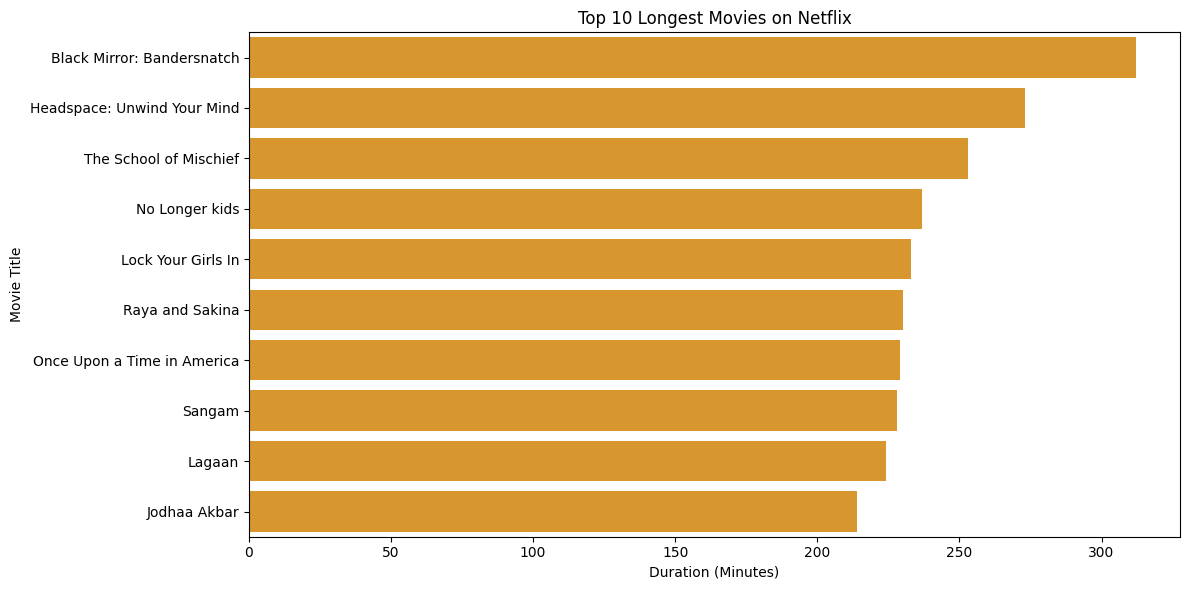

In [46]:
top_longest_movies = (
    movies[['title', 'duration_min']]
    .dropna()
    .sort_values('duration_min', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_longest_movies,
    x='duration_min',
    y='title',
    color='#F39C12'
)

plt.title('Top 10 Longest Movies on Netflix')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Movie Title')

plt.tight_layout()
plt.show()

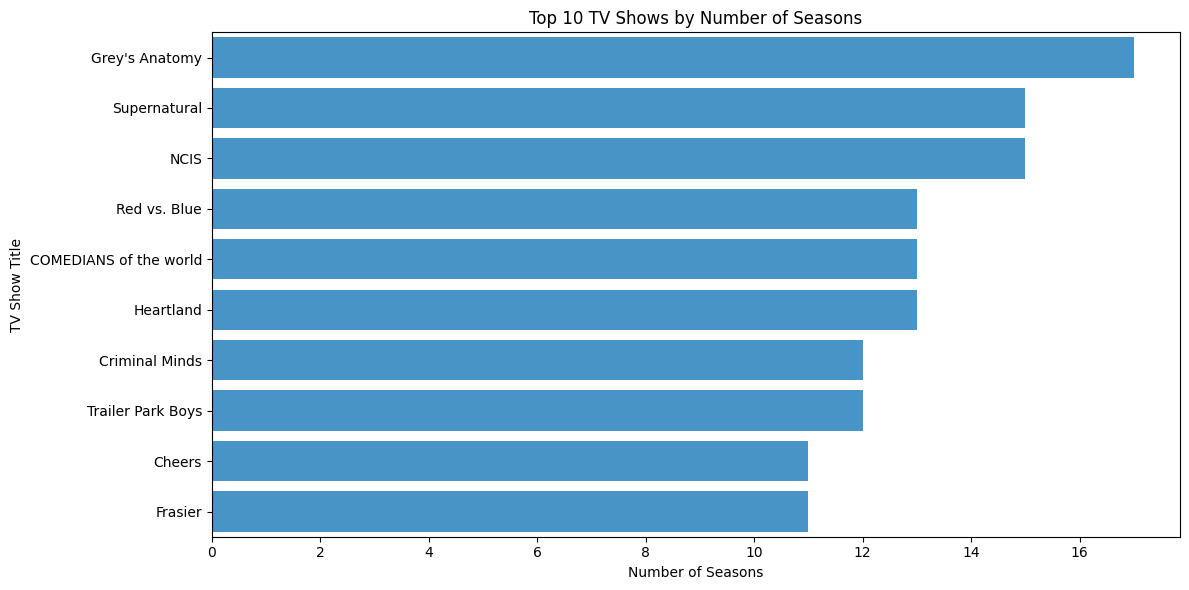

In [47]:
top_tv_shows = (
    tv_shows[['title', 'seasons']]
    .dropna()
    .sort_values('seasons', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_tv_shows,
    x='seasons',
    y='title',
    color='#3498DB'
)

plt.title('Top 10 TV Shows by Number of Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('TV Show Title')

plt.tight_layout()
plt.show()

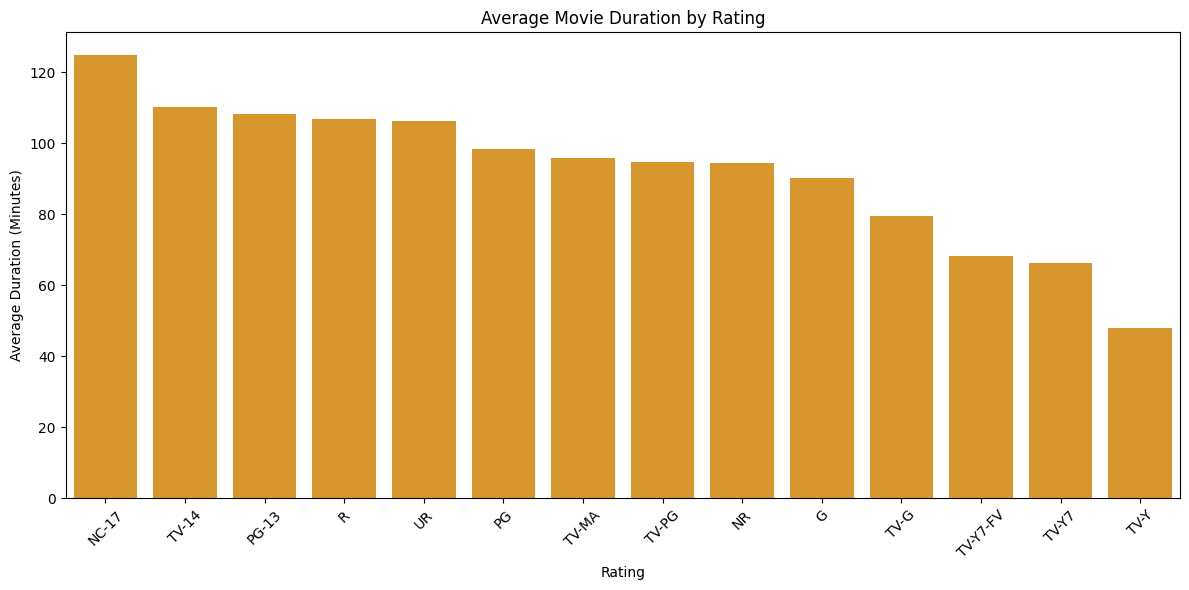

In [48]:
movie_rating_duration = (
    movies.dropna(subset=['rating', 'duration_min'])
    .groupby('rating')['duration_min']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=movie_rating_duration.index,
    y=movie_rating_duration.values,
    color='#F39C12'
)

plt.title('Average Movie Duration by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Duration (Minutes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

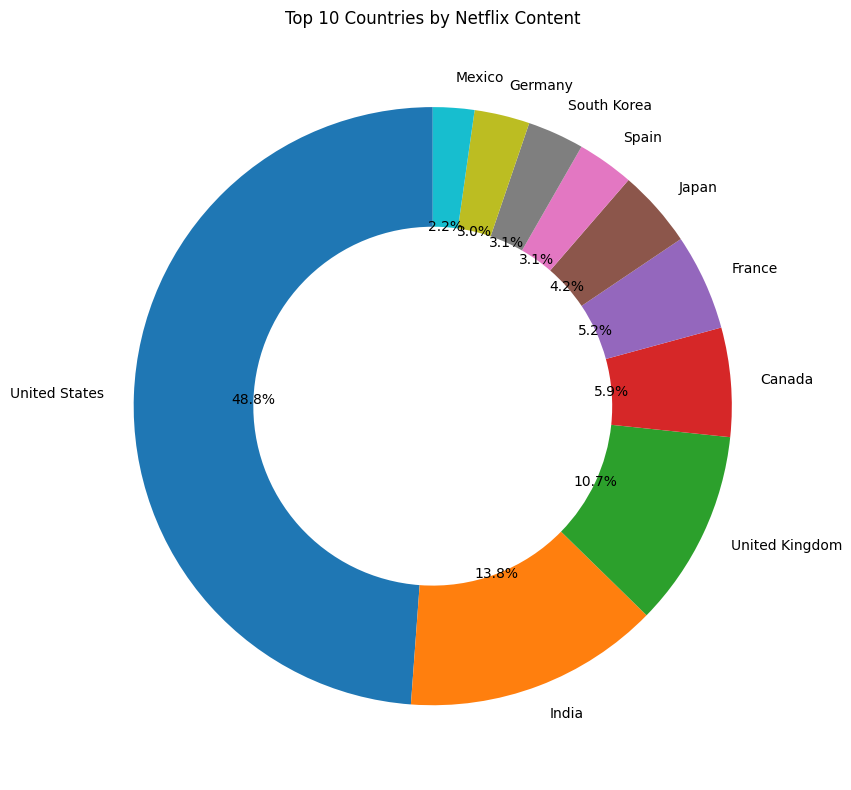

In [49]:
top_10_countries = (
    country_type['country']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 8))

plt.pie(
    top_10_countries.values,
    labels=top_10_countries.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Top 10 Countries by Netflix Content')

plt.tight_layout()
plt.show()

In [50]:
print("========== NETFLIX DATA ANALYSIS: KEY INSIGHTS ==========\n")

print(f"1. Total titles in dataset: {total_titles}")

print(
    f"2. Movies: {total_movies} "
    f"({total_movies / total_titles * 100:.2f}%)"
)

print(
    f"3. TV Shows: {total_tv_shows} "
    f"({total_tv_shows / total_titles * 100:.2f}%)"
)

print(
    f"4. Most common content type: "
    f"{df['type'].value_counts().idxmax()}"
)

print(
    f"5. Most common rating: "
    f"{df['rating'].value_counts().idxmax()}"
)

print(
    f"6. Most common release year: "
    f"{df['release_year'].value_counts().idxmax()}"
)

print(
    f"7. Average movie duration: "
    f"{average_movie_duration:.2f} minutes"
)

========== NETFLIX DATA ANALYSIS: KEY INSIGHTS ==========

1. Total titles in dataset: 8807
2. Movies: 6131 (69.62%)
3. TV Shows: 2676 (30.38%)
4. Most common content type: Movie
5. Most common rating: TV-MA
6. Most common release year: 2018
7. Average movie duration: 99.58 minutes


## Key Insights

1. The dataset contains 8,807 Netflix titles.

2. Movies account for 69.62% of the total content, while TV Shows account for 30.38%.

3. Movies are the dominant content type in the dataset.

4. TV-MA is the most common content rating.

5. 2018 is the most common release year among the titles.

6. The average movie duration is approximately 99.58 minutes.

7. Netflix content is distributed across a large number of countries and genres.

8. The dataset shows a strong presence of international content, with multiple countries contributing to the Netflix catalog.

9. The analysis of genres shows that some categories have significantly more titles than others.

10. The year-month analysis shows that Netflix's content additions varied considerably across different periods.

In [8]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print(df.shape)
df.head()

Saving netflix_titles.csv to netflix_titles.csv
Dataset loaded successfully!
(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 📊 Netflix Data Analysis Dashboard

This interactive-style dashboard summarizes key insights from the Netflix Movies and TV Shows dataset, including content distribution, countries, genres, ratings, movie duration, directors, actors, and content growth over time.

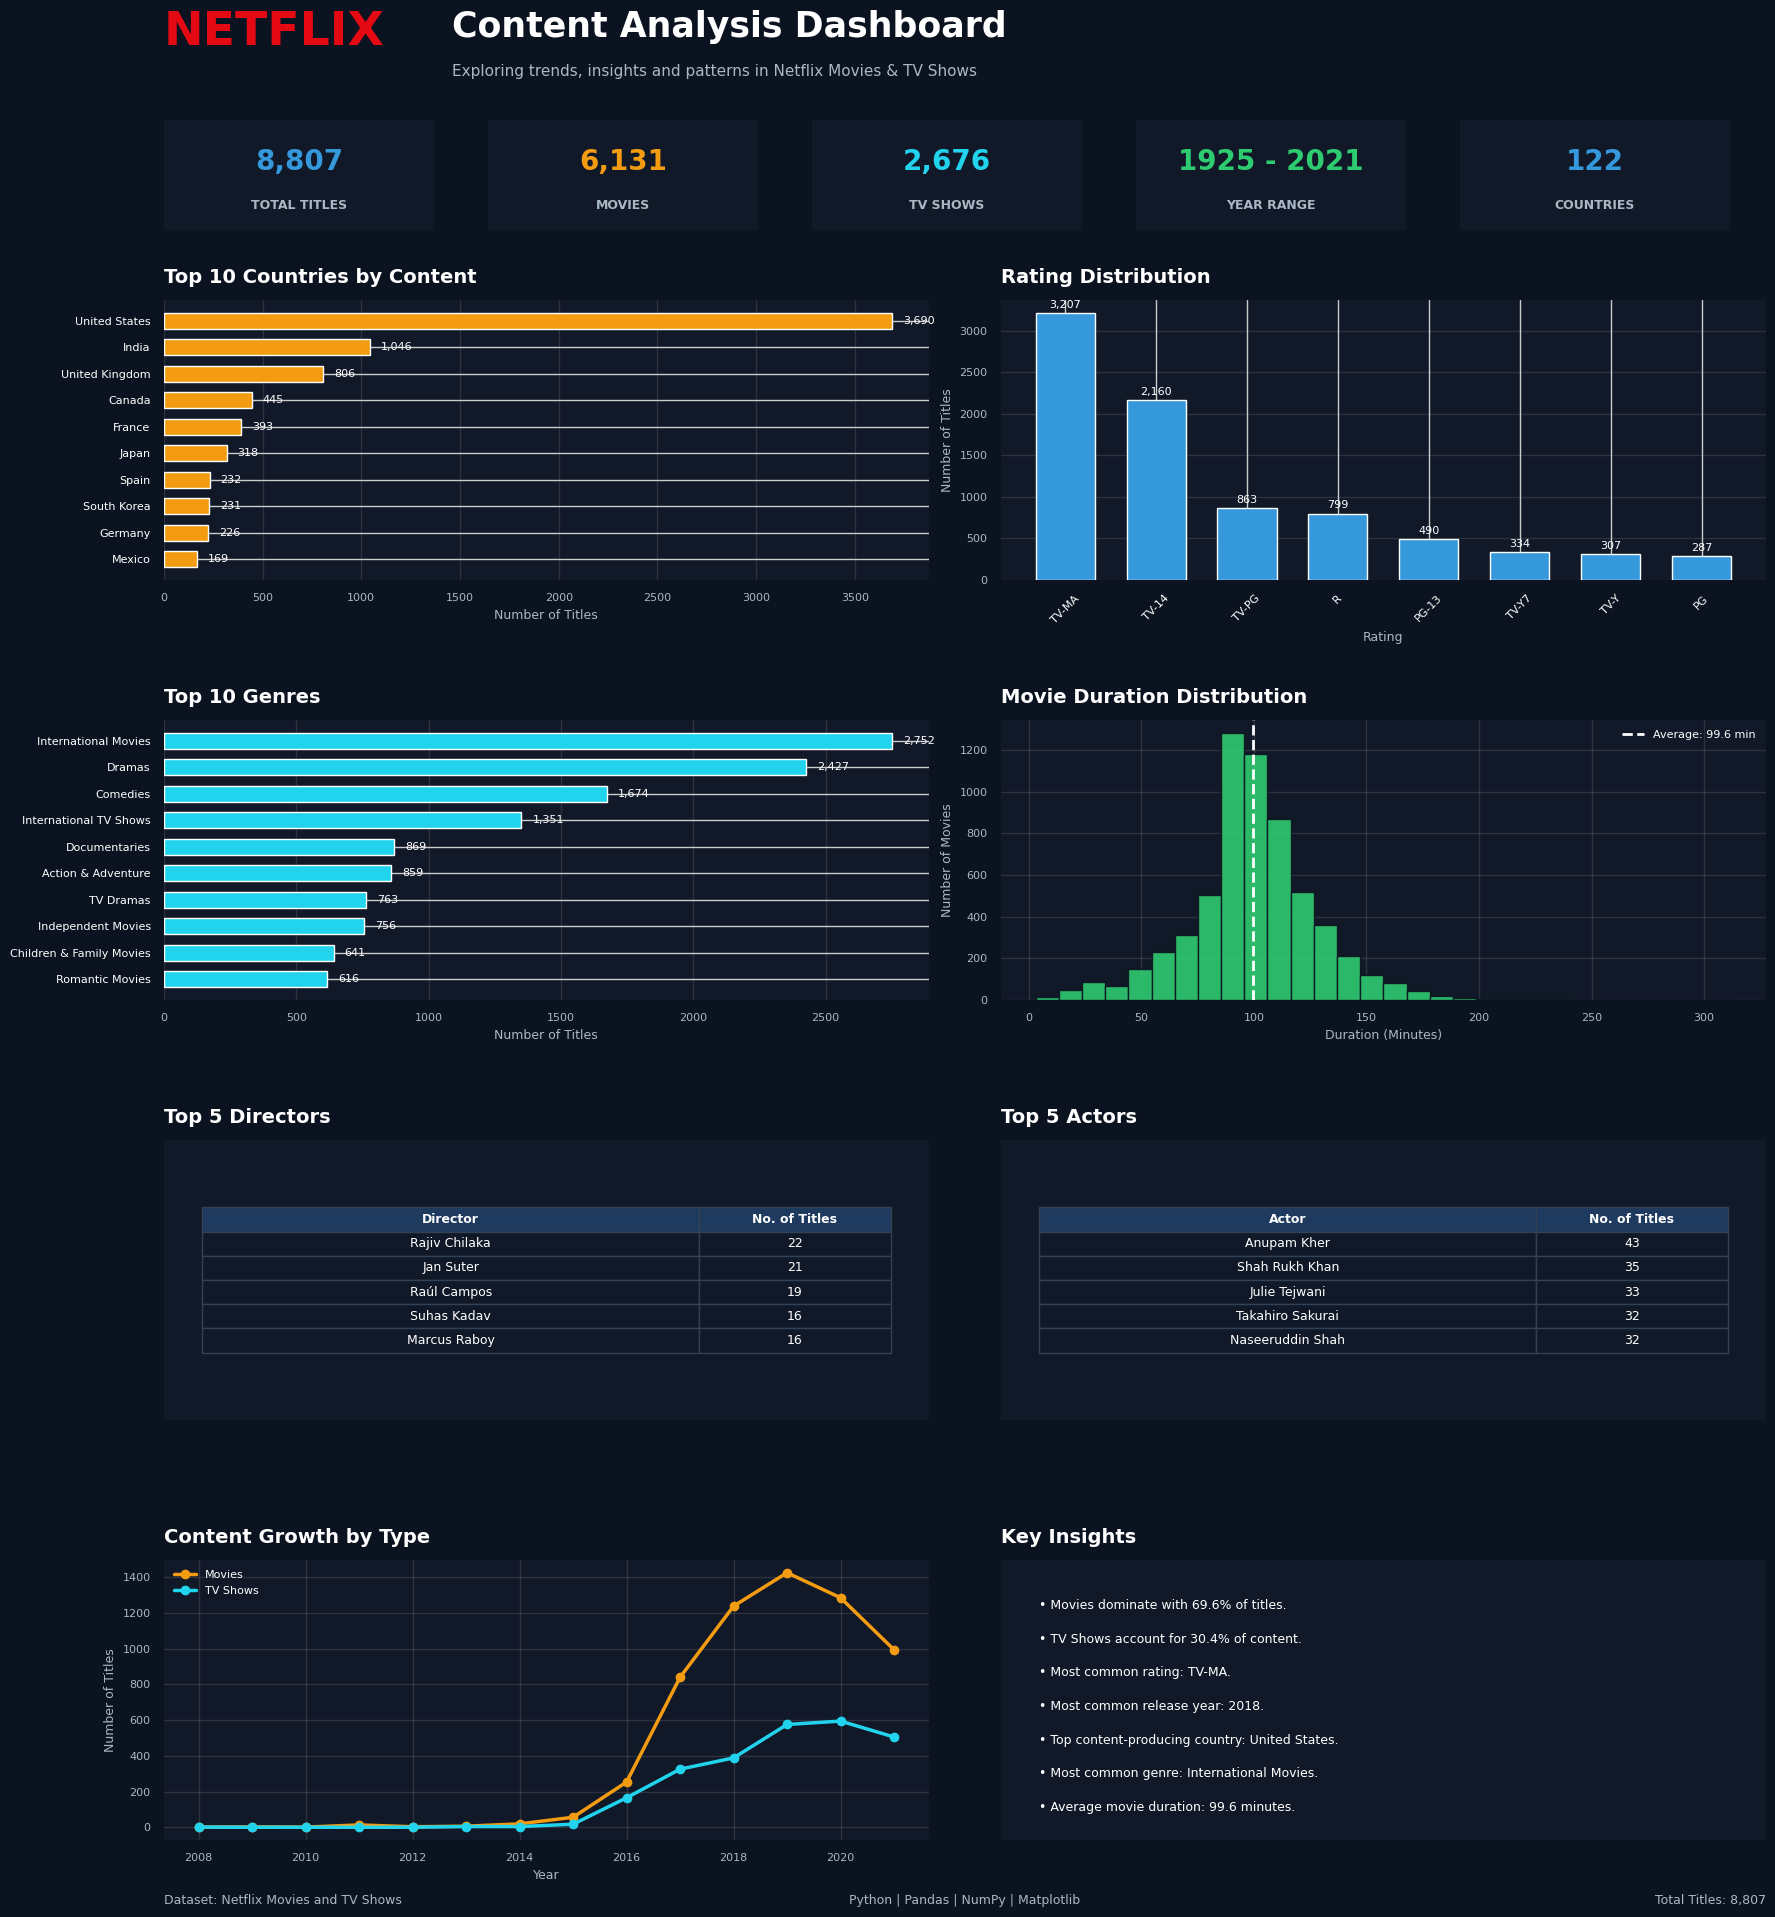

In [30]:
# ============================================================
# NETFLIX DATA ANALYSIS - CLEAN PROFESSIONAL DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ============================================================
# 1. DATA PREPARATION
# ============================================================

data = df.copy()

# Convert date
data['date_added'] = pd.to_datetime(
    data['date_added'],
    errors='coerce'
)

# ---------------- Movies ----------------

movies_dash = data[data['type'] == 'Movie'].copy()

movies_dash['duration_min'] = (
    movies_dash['duration']
    .astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(float)
)

# ---------------- Countries ----------------

country_dash = (
    data[data['country'].notna()]
    .assign(country=data['country'].str.split(','))
    .explode('country')
)

country_dash['country'] = country_dash['country'].str.strip()

country_dash = country_dash[
    country_dash['country'].ne('Unknown') &
    country_dash['country'].ne('')
]

# ---------------- Genres ----------------

genre_dash = (
    data[data['listed_in'].notna()]
    .assign(genre=data['listed_in'].str.split(','))
    .explode('genre')
)

genre_dash['genre'] = genre_dash['genre'].str.strip()

# ---------------- Directors ----------------

director_dash = (
    data[data['director'].notna()]
    .assign(director=data['director'].str.split(','))
    .explode('director')
)

director_dash['director'] = director_dash['director'].str.strip()

director_dash = director_dash[
    director_dash['director'].ne('Unknown') &
    director_dash['director'].ne('')
]

# ---------------- Actors ----------------

actor_dash = (
    data[data['cast'].notna()]
    .assign(actor=data['cast'].str.split(','))
    .explode('actor')
)

actor_dash['actor'] = actor_dash['actor'].str.strip()

actor_dash = actor_dash[
    actor_dash['actor'].ne('Unknown') &
    actor_dash['actor'].ne('')
]


# ============================================================
# 2. KPI VALUES
# ============================================================

total_titles = len(data)

total_movies = (
    data['type'] == 'Movie'
).sum()

total_tv = (
    data['type'] == 'TV Show'
).sum()

year_min = int(
    data['release_year'].min()
)

year_max = int(
    data['release_year'].max()
)

unique_countries = (
    country_dash['country'].nunique()
)

avg_movie_duration = (
    movies_dash['duration_min'].mean()
)


# ============================================================
# 3. COLORS
# ============================================================

BLUE = '#3498DB'
ORANGE = '#F39C12'
CYAN = '#22D3EE'
GREEN = '#2ECC71'

RED = '#E50914'

DARK = '#0B1320'
DARK2 = '#111827'
WHITE = '#FFFFFF'
GREY = '#AAB7C4'
BORDER = '#334155'


# ============================================================
# 4. FIGURE
# ============================================================

fig = plt.figure(
    figsize=(18, 20),
    facecolor=DARK
)


# ============================================================
# 5. HEADER
# ============================================================

fig.text(
    0.055,
    0.965,
    'NETFLIX',
    fontsize=34,
    fontweight='bold',
    color=RED,
    va='top'
)

fig.text(
    0.215,
    0.965,
    'Content Analysis Dashboard',
    fontsize=25,
    fontweight='bold',
    color=WHITE,
    va='top'
)

fig.text(
    0.215,
    0.938,
    'Exploring trends, insights and patterns in Netflix Movies & TV Shows',
    fontsize=11,
    color=GREY,
    va='top'
)


# ============================================================
# 6. KPI CARDS
# ============================================================

kpis = [
    ('TOTAL TITLES', f'{total_titles:,}', BLUE),
    ('MOVIES', f'{total_movies:,}', ORANGE),
    ('TV SHOWS', f'{total_tv:,}', CYAN),
    ('YEAR RANGE', f'{year_min} - {year_max}', GREEN),
    ('COUNTRIES', f'{unique_countries:,}', BLUE)
]

x_positions = [
    0.055,
    0.235,
    0.415,
    0.595,
    0.775
]

for x, (label, value, color) in zip(
    x_positions,
    kpis
):

    ax = fig.add_axes(
        [x, 0.855, 0.15, 0.055]
    )

    ax.axis('off')

    box = FancyBboxPatch(
        (0, 0),
        1,
        1,
        boxstyle=(
            'round,pad=0.015,'
            'rounding_size=0.04'
        ),
        facecolor=DARK2,
        edgecolor=BORDER,
        linewidth=1.5
    )

    ax.add_patch(box)

    ax.text(
        0.5,
        0.62,
        value,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold',
        color=color
    )

    ax.text(
        0.5,
        0.22,
        label,
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color=GREY
    )


# ============================================================
# 7. PANEL FUNCTION
# ============================================================

def create_panel(position, title):

    ax = fig.add_axes(position)

    ax.set_facecolor(DARK2)

    # Rounded box
    box = FancyBboxPatch(
        (0, 0),
        1,
        1,
        transform=ax.transAxes,
        boxstyle=(
            'round,pad=0.012,'
            'rounding_size=0.025'
        ),
        facecolor=DARK2,
        edgecolor=BORDER,
        linewidth=1.5,
        zorder=-1
    )

    ax.add_patch(box)

    # Title ABOVE the box
    ax.set_title(
        title,
        loc='left',
        fontsize=14,
        fontweight='bold',
        color=WHITE,
        pad=12
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    return ax


# ============================================================
# ROW 1
# TOP 10 COUNTRIES + RATING DISTRIBUTION
# ============================================================


# ---------------- TOP COUNTRIES ----------------

ax1 = create_panel(
    [0.055, 0.68, 0.425, 0.14],
    'Top 10 Countries by Content'
)

top_countries = (
    country_dash['country']
    .value_counts()
    .head(10)
    .sort_values()
)

country_names = top_countries.index.tolist()
country_values = top_countries.values.astype(float)

y_pos = np.arange(
    len(country_names)
)

ax1.barh(
    y_pos,
    country_values,
    color=ORANGE,
    height=0.60
)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(
    country_names
)

ax1.set_xlabel(
    'Number of Titles',
    color=GREY,
    fontsize=9
)

ax1.tick_params(
    axis='x',
    colors=GREY,
    labelsize=8
)

ax1.tick_params(
    axis='y',
    colors=WHITE,
    labelsize=8
)

ax1.grid(
    axis='x',
    alpha=0.15
)

for i, value in enumerate(
    country_values
):

    ax1.text(
        value + country_values.max() * 0.015,
        i,
        f'{int(value):,}',
        va='center',
        fontsize=8,
        color=WHITE
    )


# ---------------- RATING DISTRIBUTION ----------------

ax2 = create_panel(
    [0.52, 0.68, 0.425, 0.14],
    'Rating Distribution'
)

rating_counts = (
    data['rating']
    .dropna()
    .value_counts()
    .head(8)
)

bars = ax2.bar(
    rating_counts.index,
    rating_counts.values,
    color=BLUE,
    width=0.65
)

ax2.set_xlabel(
    'Rating',
    color=GREY,
    fontsize=9
)

ax2.set_ylabel(
    'Number of Titles',
    color=GREY,
    fontsize=9
)

ax2.tick_params(
    axis='x',
    colors=WHITE,
    labelsize=8,
    rotation=45
)

ax2.tick_params(
    axis='y',
    colors=GREY,
    labelsize=8
)

ax2.grid(
    axis='y',
    alpha=0.15
)

for bar, value in zip(
    bars,
    rating_counts.values
):

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + rating_counts.max() * 0.02,
        f'{value:,}',
        ha='center',
        fontsize=8,
        color=WHITE
    )


# ============================================================
# ROW 2
# TOP 10 GENRES + MOVIE DURATION
# ============================================================


# ---------------- TOP GENRES ----------------

ax3 = create_panel(
    [0.055, 0.47, 0.425, 0.14],
    'Top 10 Genres'
)

top_genres = (
    genre_dash['genre']
    .value_counts()
    .head(10)
    .sort_values()
)

genre_names = top_genres.index.tolist()
genre_values = top_genres.values.astype(float)

y_pos = np.arange(
    len(genre_names)
)

ax3.barh(
    y_pos,
    genre_values,
    color=CYAN,
    height=0.60
)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(
    genre_names
)

ax3.set_xlabel(
    'Number of Titles',
    color=GREY,
    fontsize=9
)

ax3.tick_params(
    axis='x',
    colors=GREY,
    labelsize=8
)

ax3.tick_params(
    axis='y',
    colors=WHITE,
    labelsize=8
)

ax3.grid(
    axis='x',
    alpha=0.15
)

for i, value in enumerate(
    genre_values
):

    ax3.text(
        value + genre_values.max() * 0.015,
        i,
        f'{int(value):,}',
        va='center',
        fontsize=8,
        color=WHITE
    )


# ---------------- MOVIE DURATION ----------------

ax4 = create_panel(
    [0.52, 0.47, 0.425, 0.14],
    'Movie Duration Distribution'
)

duration_data = (
    movies_dash['duration_min']
    .dropna()
)

ax4.hist(
    duration_data,
    bins=30,
    color=GREEN,
    edgecolor=DARK,
    alpha=0.9
)

ax4.axvline(
    avg_movie_duration,
    color=WHITE,
    linestyle='--',
    linewidth=2,
    label=(
        f'Average: '
        f'{avg_movie_duration:.1f} min'
    )
)

ax4.set_xlabel(
    'Duration (Minutes)',
    color=GREY,
    fontsize=9
)

ax4.set_ylabel(
    'Number of Movies',
    color=GREY,
    fontsize=9
)

ax4.tick_params(
    colors=GREY,
    labelsize=8
)

ax4.grid(
    alpha=0.15
)

ax4.legend(
    fontsize=8,
    facecolor=DARK2,
    labelcolor=WHITE,
    frameon=False
)


# ============================================================
# ROW 3
# TOP 5 DIRECTORS + TOP 5 ACTORS
# ============================================================


# ---------------- TOP DIRECTORS ----------------

ax5 = create_panel(
    [0.055, 0.26, 0.425, 0.14],
    'Top 5 Directors'
)

top_directors = (
    director_dash['director']
    .value_counts()
    .head(5)
)

ax5.axis('off')

director_table_data = []

for director, count in top_directors.items():

    director_table_data.append([
        director,
        f'{count:,}'
    ])

table = ax5.table(
    cellText=director_table_data,
    colLabels=[
        'Director',
        'No. of Titles'
    ],
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[
        0.65,
        0.25
    ]
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.45)

for cell in table.get_celld().values():

    cell.set_edgecolor(BORDER)
    cell.set_facecolor(DARK2)

    cell.set_text_props(
        color=WHITE
    )

# Header cells
for (row, col), cell in table.get_celld().items():

    if row == 0:

        cell.set_facecolor(
            '#1E3A5F'
        )

        cell.set_text_props(
            color=WHITE,
            fontweight='bold'
        )


# ---------------- TOP ACTORS ----------------

ax6 = create_panel(
    [0.52, 0.26, 0.425, 0.14],
    'Top 5 Actors'
)

top_actors = (
    actor_dash['actor']
    .value_counts()
    .head(5)
)

ax6.axis('off')

actor_table_data = []

for actor, count in top_actors.items():

    actor_table_data.append([
        actor,
        f'{count:,}'
    ])

table2 = ax6.table(
    cellText=actor_table_data,
    colLabels=[
        'Actor',
        'No. of Titles'
    ],
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[
        0.65,
        0.25
    ]
)

table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.45)

for cell in table2.get_celld().values():

    cell.set_edgecolor(BORDER)
    cell.set_facecolor(DARK2)

    cell.set_text_props(
        color=WHITE
    )

# Header cells
for (row, col), cell in table2.get_celld().items():

    if row == 0:

        cell.set_facecolor(
            '#1E3A5F'
        )

        cell.set_text_props(
            color=WHITE,
            fontweight='bold'
        )


# ============================================================
# ROW 4
# CONTENT GROWTH + KEY INSIGHTS
# ============================================================


# ---------------- CONTENT GROWTH ----------------

ax7 = create_panel(
    [0.055, 0.05, 0.425, 0.14],
    'Content Growth by Type'
)

growth_data = (
    data
    .dropna(subset=['date_added'])
    .copy()
)

growth_data['added_year'] = (
    growth_data['date_added'].dt.year
)

growth_type = (
    growth_data
    .groupby(
        ['added_year', 'type']
    )
    .size()
    .unstack(fill_value=0)
)

if 'Movie' in growth_type.columns:

    ax7.plot(
        growth_type.index,
        growth_type['Movie'],
        marker='o',
        linewidth=2.5,
        color=ORANGE,
        label='Movies'
    )

if 'TV Show' in growth_type.columns:

    ax7.plot(
        growth_type.index,
        growth_type['TV Show'],
        marker='o',
        linewidth=2.5,
        color=CYAN,
        label='TV Shows'
    )

ax7.set_xlabel(
    'Year',
    color=GREY,
    fontsize=9
)

ax7.set_ylabel(
    'Number of Titles',
    color=GREY,
    fontsize=9
)

ax7.tick_params(
    colors=GREY,
    labelsize=8
)

ax7.grid(
    alpha=0.15
)

ax7.legend(
    fontsize=8,
    frameon=False,
    labelcolor=WHITE
)


# ---------------- KEY INSIGHTS ----------------

ax8 = create_panel(
    [0.52, 0.05, 0.425, 0.14],
    'Key Insights'
)

ax8.axis('off')

most_rating = (
    data['rating']
    .value_counts()
    .idxmax()
)

most_year = (
    data['release_year']
    .value_counts()
    .idxmax()
)

top_country = (
    country_dash['country']
    .value_counts()
    .idxmax()
)

top_genre = (
    genre_dash['genre']
    .value_counts()
    .idxmax()
)

insights = [

    f'• Movies dominate with '
    f'{total_movies / total_titles * 100:.1f}% of titles.',

    f'• TV Shows account for '
    f'{total_tv / total_titles * 100:.1f}% of content.',

    f'• Most common rating: '
    f'{most_rating}.',

    f'• Most common release year: '
    f'{most_year}.',

    f'• Top content-producing country: '
    f'{top_country}.',

    f'• Most common genre: '
    f'{top_genre}.',

    f'• Average movie duration: '
    f'{avg_movie_duration:.1f} minutes.'
]

y = 0.86

for insight in insights:

    ax8.text(
        0.05,
        y,
        insight,
        fontsize=9,
        color=WHITE,
        va='top'
    )

    y -= 0.12


# ============================================================
# FOOTER
# ============================================================

fig.text(
    0.055,
    0.018,
    'Dataset: Netflix Movies and TV Shows',
    fontsize=9,
    color=GREY
)

fig.text(
    0.5,
    0.018,
    'Python | Pandas | NumPy | Matplotlib',
    ha='center',
    fontsize=9,
    color=GREY
)

fig.text(
    0.945,
    0.018,
    f'Total Titles: {total_titles:,}',
    ha='right',
    fontsize=9,
    color=GREY
)


# ============================================================
# SAVE + SHOW
# ============================================================

plt.savefig(
    'Netflix_Data_Analysis_Dashboard.png',
    dpi=250,
    bbox_inches='tight',
    facecolor=fig.get_facecolor()
)

plt.show()

# 📌 Conclusion

The analysis of the Netflix Movies and TV Shows dataset provides useful insights into Netflix's content catalog.

- Movies represent the majority of the available titles.
- TV-MA is the most common content rating.
- The United States contributes the largest number of titles in the dataset.
- International Movies is one of the most prominent genres.
- The average movie duration is approximately 100 minutes.
- Netflix content additions varied across different years and periods.
- The dataset contains a wide variety of countries, genres, ratings, directors, and actors.

Overall, the analysis demonstrates how Python and data visualization can be used to identify patterns and trends in a large content dataset.

# 📝 Project Summary

This project performs exploratory data analysis on the Netflix Movies and TV Shows dataset using Python.

The analysis includes data cleaning, missing-value handling, content-type analysis, country and genre analysis, rating distribution, movie duration analysis, director and actor analysis, and content growth trends.

A professional dashboard was created using Matplotlib to present the major findings in a clear and visual format.

### 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

# 📊 Netflix Data Analysis using Python

## 📌 Project Overview

This project performs exploratory data analysis on the Netflix Movies and TV Shows dataset using Python.

The project focuses on understanding Netflix's content catalog through data cleaning, statistical analysis, and data visualization.

## 🎯 Objectives

- Analyze Movies and TV Shows distribution
- Identify top content-producing countries
- Analyze popular genres
- Study rating distribution
- Analyze movie duration
- Identify top directors and actors
- Analyze Netflix content growth over time
- Present findings through a professional dashboard

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## 📂 Dataset

The dataset contains information about Netflix Movies and TV Shows, including:

- Title
- Content Type
- Director
- Cast
- Country
- Release Year
- Rating
- Duration
- Genre
- Date Added

## 📊 Analysis Performed

- Movies vs TV Shows
- Top 10 Countries
- Top 10 Genres
- Rating Distribution
- Movie Duration Distribution
- Top 5 Directors
- Top 5 Actors
- Content Growth by Type
- Key Insights

## 📈 Dashboard

A professional Netflix dashboard was created using Matplotlib to present the major findings in a clear and visual format.

## 🔍 Key Findings

- Movies represent the majority of titles in the dataset.
- TV-MA is the most common rating.
- The United States contributes the largest number of titles.
- International Movies is one of the most prominent genres.
- The average movie duration is approximately 100 minutes.
- Content additions vary across different years.

## 👨‍💻 Author

**Aaruhi Kumari**

Data Analytics | Python | SQL | Data Visualization